# Amazon Sponsored Ads Performance Analysis

**Dataset:** `Amazon_Search_Term_Report.xlsx`

## Objective

Analyze Amazon Sponsored Ads search term performance to identify:

* Inefficient ad spend (wasted clicks / high ACOS)
* High-performing search terms (low ACOS + strong CVR)
* Practical optimization actions (negative keywords, bid adjustments, match-type strategy)

> This notebook is structured for portfolio / interview presentation: clear narrative → clean metrics → actionable insights.

In [1]:
# 1) Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## 2) Load data

This report is typically exported from Amazon Ads as a **Search Term Report**.  
Each row represents a customer search term triggered by an ad target/keyword, along with performance metrics over the selected date range.

In [2]:
import os
os.getcwd()

'd:\\文件\\amazon-sponsored-ads-analysis\\notebooks'

In [3]:
%cd D:/文件/amazon-sponsored-ads-analysis/data

D:\文件\amazon-sponsored-ads-analysis\data


In [4]:
!dir

 Volume in drive D is ???
 Volume Serial Number is 14C4-3D8C

 Directory of D:\??\amazon-sponsored-ads-analysis\data

2026-03-16  05:19 PM    <DIR>          .
2026-03-16  05:11 PM    <DIR>          ..
2026-01-24  11:57 PM            51,829 Amazon_Search_Term_Report.xlsx
               1 File(s)         51,829 bytes
               2 Dir(s)  151,960,391,680 bytes free


In [5]:
# Load Excel
df_raw = pd.read_excel("Amazon_Search_Term_Report.xlsx")

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (492, 25)


,Start Date,End Date,Campaign Group Name,Currency,Campaign Name,Ad Group Name,Country / Region,Targeting Type,Match Type,Customer Search Term,Impressions,Clicks,CTR,CPC,Spend,7 Day Total Sales,Total ACOS,Total ROAS,7 Day Total Orders,7 Day Total Units,7 Day Conversion Rate,7 Day Advertised SKU Units,7 Day Other SKU Units,7 Day Advertised SKU Sales,7 Day Other SKU Sales
0,2026-01-11,2026-01-11,Protective Gear,CAD,Protective Pads-Auto Campaign,Pads-Auto Campaign,Canada,close-match,-,adjustable skates￼,4,1,0.25,0.80,0.80,0.00,NaN,0.000000,0,0,0.0,0,0,0.00,0.0
1,2025-12-28,2025-12-28,Impact Gloves,CAD,Impact Gloves-Manual Campaign,Impact Gloves-Manual Campaign,Canada,ski gloves with wrist guards,BROAD,adult ski gloves with wrist guard,2,1,0.50,0.60,0.60,49.99,0.012002,83.316667,1,1,1.0,1,0,49.99,0.0
2,2026-01-05,2026-01-05,3M Gloves,CAD,3M Gloves-Manual Campaign,3M Gloves-Manual Campaign,Canada,ski glove,PHRASE,alpine ski gloves,1,1,1.00,0.61,0.61,0.00,NaN,0.000000,0,0,0.0,0,0,0.00,0.0
3,2026-01-01,2026-01-01,Impact Gloves,CAD,Impact Gloves-ASIN Targeting Campaign,Old Gloves_ASIN Targeting_Nov,Canada,"asin-expanded=""B073XND5NH""",-,arctic glove,2,1,0.50,0.67,0.67,0.00,NaN,0.000000,0,0,0.0,0,0,0.00,0.0
4,2026-01-17,2026-01-17,Ski Socks,CAD,SocksAuto Campaign,Socks - Auto Campaign,Canada,substitutes,-,b000v5i95c,10,1,0.10,1.07,1.07,0.00,NaN,0.000000,0,0,0.0,0,0,0.00,0.0


## 3) Data cleaning & standardization

I standardized the column names and retained only the fields required for performance analysis.  
I also handled missing values and enforced numeric data types to prevent calculation issues.

In [6]:
# --- Column Standardization ---
# Column names vary by account language (English/Chinese).
# A mapping dictionary is used to ensure consistent schema for downstream analysis.

col_map = {
    # English exports
    "Campaign Name": "campaign",
    "Ad Group Name": "ad_group",
    "Customer Search Term": "search_term",
    "Impressions": "impressions",
    "Clicks": "clicks",
    "Spend": "spend",
    "7 Day Total Sales": "sales",
    "7 Day Total Orders": "orders",
    "Match Type": "match_type",
    "Targeting Type": "targeting_type",
    "Targeting": "targeting",
    # Chinese exports (common fields)
    "广告活动名称": "campaign",
    "广告组名称": "ad_group",
    "客户搜索词": "search_term",
    "展示量": "impressions",
    "点击量": "clicks",
    "花费": "spend",
    "7天总销售额": "sales",
    "7天总订单数(#)": "orders",
    "匹配类型": "match_type",
    "投放": "targeting_type",
    "Targeting Type": "targeting_type",
}

# Rename columns
df = df_raw.rename(columns=col_map).copy()

# Keep only the columns we need
wanted_cols = ["campaign","ad_group","match_type","targeting_type","targeting","search_term",
               "impressions","clicks","spend","sales","orders"]
existing_cols = [c for c in wanted_cols if c in df.columns]
df = df[existing_cols].copy()

# Fill missing values
df = df.fillna(0)

# Convert numeric columns
numeric_cols = ["impressions","clicks","spend","sales","orders"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
        
df.head()

,campaign,ad_group,match_type,targeting_type,search_term,impressions,clicks,spend,sales,orders
0,Protective Pads-Auto Campaign,Pads-Auto Campaign,-,close-match,adjustable skates￼,4,1,0.80,0.00,0
1,Impact Gloves-Manual Campaign,Impact Gloves-Manual Campaign,BROAD,ski gloves with wrist guards,adult ski gloves with wrist guard,2,1,0.60,49.99,1
2,3M Gloves-Manual Campaign,3M Gloves-Manual Campaign,PHRASE,ski glove,alpine ski gloves,1,1,0.61,0.00,0
3,Impact Gloves-ASIN Targeting Campaign,Old Gloves_ASIN Targeting_Nov,-,"asin-expanded=""B073XND5NH""",arctic glove,2,1,0.67,0.00,0
4,SocksAuto Campaign,Socks - Auto Campaign,-,substitutes,b000v5i95c,10,1,1.07,0.00,0


### Quick QA checks

* Duplicate records are expected in search term reports, as the same search term may appear across different campaigns or ad groups.
* I focus primarily on aggregated performance at the search term level and by campaign/match type.

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
campaign,492,12,Impact Gloves-Auto Campaign,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ad_group,492,12,Ad TestNov2 Old Gloves,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_type,492,4,-,324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
targeting_type,492,32,close-match,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
search_term,492,395,snowboard gloves,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
impressions,492.0,NaN,NaN,NaN,62.550813,327.287742,1.0,2.0,4.0,15.0,4997.0
clicks,492.0,NaN,NaN,NaN,1.930894,3.446315,1.0,1.0,1.0,2.0,43.0
spend,492.0,NaN,NaN,NaN,1.564797,3.281849,0.03,0.66,0.8,1.2775,43.95
sales,492.0,NaN,NaN,NaN,4.826199,17.14867,0.0,0.0,0.0,0.0,149.97
orders,492.0,NaN,NaN,NaN,0.103659,0.354527,0.0,0.0,0.0,0.0,3.0


## Exploratory Data Analysis (EDA) Summary

### Dataset Overview

* The dataset contains **492 rows**, with no major missing values in numeric fields, indicating good data completeness.
* There are **12 campaigns** and **4 match types**.
* Among 492 rows, there are **395 unique search terms**, meaning some terms were triggered across multiple campaigns or ad groups.

---

### Distribution Observations

* **Impressions are highly skewed**
  + Mean = 62.55
  + Max = 4,997
  + Min = 1→ A small number of search terms receive significantly higher exposure.
* **Clicks are concentrated**
  + Average clicks per term < 2
  + Maximum clicks = 43→ Traffic distribution is uneven across terms.
* **Clicks are concentrated**
  + Average clicks per term < 2
  + Maximum clicks = 43→ Traffic distribution is uneven across terms.
* **Sales distribution is heavily skewed**
  + Mean = 4.83
  + 50th percentile = 0→ More than half of search terms generated no sales.
* **Orders show a long-tail pattern**
  + Over 50% of terms have zero orders
  + Maximum orders per term = 3→ Revenue is driven by a small number of high-performing search terms.

---

### Key Business Questions

Based on the initial EDA, I identified the following questions:

1. Do a small number of search terms contribute to the majority of total sales? (Pareto effect)
2. How much advertising spend is allocated to non-converting search terms?
3. Are there extreme outliers impacting performance metrics?

---

### Next Analytical Steps

To further investigate, I performed:

* ACOS distribution analysis to evaluate profitability spread
* Spend vs. Sales scatter analysis to assess return efficiency
* Segmentation analysis to classify:
  + Waste terms (high clicks, zero orders)
  + High-performing terms (low ACOS, strong CVR)
  + Loss-making terms (high ACOS)

---

### Initial Insight

The data suggests a highly concentrated revenue structure, where a small subset of search terms drives most sales, while many terms generate traffic without conversions. This indicates potential opportunities for:

* Negative keyword implementation
* Budget reallocation
* Bid optimization
* Match-type refinement

## 4) Feature engineering: CTR, CVR, ACOS, ROAS

* CTR = Clicks / Impressions
* CVR = Orders / Clicks
* ACOS = Spend / Sales
* ROAS = Sales / Spend

I use safe division to avoid divide-by-zero errors.

In [8]:
# Safe division helper
def safe_divide(a, b):
    # returns 0 when denominator is 0
    return np.where(b == 0, 0, a / b)

df["CTR"]  = safe_divide(df["clicks"], df["impressions"])
df["CVR"]  = safe_divide(df["orders"], df["clicks"])
df["ACOS"] = safe_divide(df["spend"], df["sales"])
df["ROAS"] = safe_divide(df["sales"], df["spend"])

df.head()

,campaign,ad_group,match_type,targeting_type,search_term,impressions,clicks,spend,sales,orders,CTR,CVR,ACOS,ROAS
0,Protective Pads-Auto Campaign,Pads-Auto Campaign,-,close-match,adjustable skates￼,4,1,0.80,0.00,0,0.25,0.0,0.000000,0.000000
1,Impact Gloves-Manual Campaign,Impact Gloves-Manual Campaign,BROAD,ski gloves with wrist guards,adult ski gloves with wrist guard,2,1,0.60,49.99,1,0.50,1.0,0.012002,83.316667
2,3M Gloves-Manual Campaign,3M Gloves-Manual Campaign,PHRASE,ski glove,alpine ski gloves,1,1,0.61,0.00,0,1.00,0.0,0.000000,0.000000
3,Impact Gloves-ASIN Targeting Campaign,Old Gloves_ASIN Targeting_Nov,-,"asin-expanded=""B073XND5NH""",arctic glove,2,1,0.67,0.00,0,0.50,0.0,0.000000,0.000000
4,SocksAuto Campaign,Socks - Auto Campaign,-,substitutes,b000v5i95c,10,1,1.07,0.00,0,0.10,0.0,0.000000,0.000000


## 5) Aggregate analysis: search term level

In [9]:
agg_cols = ["impressions","clicks","spend","sales","orders"]

df_term = df.groupby("search_term", as_index=False)[agg_cols].sum()

df_term["CTR"]  = safe_divide(df_term["clicks"], df_term["impressions"])
df_term["CVR"]  = safe_divide(df_term["orders"], df_term["clicks"])
df_term["ACOS"] = safe_divide(df_term["spend"], df_term["sales"])
df_term["ROAS"] = safe_divide(df_term["sales"], df_term["spend"])

df_term.sort_values("sales", ascending=False).head(15)

,search_term,impressions,clicks,spend,sales,orders,CTR,CVR,ACOS,ROAS
268,snowboard mitts,1217,48,47.19,149.97,3,0.039441,0.062500,0.314663,3.178004
241,snowboard gloves,2072,66,45.77,149.97,3,0.031853,0.045455,0.305194,3.276600
254,snowboard gloves with wrist guard,4335,47,46.57,149.97,3,0.010842,0.063830,0.310529,3.220314
256,snowboard gloves women,57,11,8.93,109.98,2,0.192982,0.181818,0.081197,12.315789
5,b00bhmhu9o,889,14,10.36,99.98,2,0.015748,0.142857,0.103621,9.650579
7,b073xnd5nh,659,26,18.23,99.98,2,0.039454,0.076923,0.182336,5.484366
180,ski gloves men,622,14,11.33,94.98,2,0.022508,0.142857,0.119288,8.383054
178,ski gloves,5602,48,41.49,70.98,2,0.008568,0.041667,0.584531,1.710774
261,snowboard knee and butt pads,1,1,0.92,65.99,1,1.000000,1.000000,0.013942,71.728261
278,snowboard protective gear sets,5,1,0.17,65.99,1,0.200000,1.000000,0.002576,388.176471


### Top Revenue Drivers Analysis

* **Sales are concentrated around core “snowboard gloves” related search terms.**  
  The top revenue drivers are dominated by snowboard glove–related queries. For example,
  “snowboard mitts”, “snowboard gloves”, and “snowboard gloves with wrist guard” each generated **$149.97** in sales,
  and “snowboard gloves women” generated **$109.98**.  
  This suggests customer demand and purchase intent are strongly aligned with the core product theme (snowboard gloves/mitts),
  and these terms are key contributors to total revenue.
* **Several high-CVR keywords show strong profitability and may justify higher bids.**  
  Some terms combine strong conversion efficiency (high CVR) with low advertising cost relative to revenue (low ACOS).  
  For example, “snowboard gloves women” shows **CVR = 18.18%** and **ACOS = 8.12%**, indicating strong profitability and scaling potential.  
  “ski gloves men” also performs well with **CVR = 14.29%** and **ACOS = 11.93%**.  
  These keywords are good candidates for controlled bid increases, tighter match types (e.g., Exact), and budget allocation.
* **Some high-impression terms exhibit relatively high ACOS, indicating optimization potential.**  
  Not all high-traffic terms are cost-efficient. For example, “ski gloves” has very high exposure (**5,602 impressions**)
  but shows **ACOS = 58.45%** and **ROAS = 1.71**, meaning spend is relatively high compared to sales generated.  
  This indicates optimization opportunities such as bid reduction, refining match type/targeting, or improving product relevance for that query.
* **Extremely high ROAS values are driven by very small sample sizes and should be interpreted cautiously.**  
  Some terms show extremely high ROAS (e.g., “snowboard protective gear sets” with **ROAS ≈ 388**),
  but this result is based on very limited data (e.g., only a few impressions/clicks).  
  With such small sample sizes, metrics can look unrealistically good due to randomness. These terms should be monitored,
  but not used alone to make major budget decisions until more data is collected.

## 6) Segmentation: waste vs opportunity vs loss-making

I classify search terms into 3 groups:

* **Waste terms**: Clicks > 10 and Orders = 0
* **High performers**: CVR ≥ 10% and ACOS ≤ 25%
* **Loss-making**: ACOS ≥ 50% and Sales > 0

In [10]:
# Thresholds 
WASTE_CLICKS = 10
HIGH_CVR = 0.10
GOOD_ACOS = 0.25
BAD_ACOS = 0.50

waste_terms = df_term[(df_term["clicks"] > WASTE_CLICKS) & (df_term["orders"] == 0)].copy()
high_perf   = df_term[(df_term["CVR"] >= HIGH_CVR) & (df_term["ACOS"] > 0) & (df_term["ACOS"] <= GOOD_ACOS)].copy()
loss_making = df_term[(df_term["ACOS"] >= BAD_ACOS) & (df_term["sales"] > 0)].copy()

segment_summary = pd.DataFrame({
    "segment": ["waste_terms", "high_perf", "loss_making"],
    "count": [len(waste_terms), len(high_perf), len(loss_making)],
    "total_spend": [waste_terms["spend"].sum(), high_perf["spend"].sum(), loss_making["spend"].sum()],
    "total_sales": [waste_terms["sales"].sum(), high_perf["sales"].sum(), loss_making["sales"].sum()],
    "total_orders":[waste_terms["orders"].sum(), high_perf["orders"].sum(), loss_making["orders"].sum()],
})

segment_summary

,segment,count,total_spend,total_sales,total_orders
0,waste_terms,5,64.64,0.00,0
1,high_perf,34,77.69,1718.63,37
2,loss_making,1,41.49,70.98,2


### Top examples per segment

In [11]:
show_cols = ["search_term","impressions","clicks","spend","sales","orders","CTR","CVR","ACOS","ROAS"]

waste_terms.sort_values("spend", ascending=False).head(15)[show_cols]

,search_term,impressions,clicks,spend,sales,orders,CTR,CVR,ACOS,ROAS
189,ski gloves women,1277,21,17.35,0.0,0,0.016445,0.0,0.0,0.0
245,snowboard gloves men,367,20,14.97,0.0,0,0.054496,0.0,0.0,0.0
225,snowboard,519,12,12.10,0.0,0,0.023121,0.0,0.0,0.0
15,b081pk2pfg,1250,12,11.31,0.0,0,0.009600,0.0,0.0,0.0
291,snowboarding gloves,201,11,8.91,0.0,0,0.054726,0.0,0.0,0.0


In [12]:
high_perf.sort_values("sales", ascending=False).head(15)[show_cols]

,search_term,impressions,clicks,spend,sales,orders,CTR,CVR,ACOS,ROAS
256,snowboard gloves women,57,11,8.93,109.98,2,0.192982,0.181818,0.081197,12.315789
5,b00bhmhu9o,889,14,10.36,99.98,2,0.015748,0.142857,0.103621,9.650579
180,ski gloves men,622,14,11.33,94.98,2,0.022508,0.142857,0.119288,8.383054
261,snowboard knee and butt pads,1,1,0.92,65.99,1,1.000000,1.000000,0.013942,71.728261
278,snowboard protective gear sets,5,1,0.17,65.99,1,0.200000,1.000000,0.002576,388.176471
276,snowboard pads,12,3,2.31,65.99,1,0.250000,0.333333,0.035005,28.567100
364,women's ski glove,1,1,0.90,59.99,1,1.000000,1.000000,0.015003,66.655556
264,snowboard mitt,1,1,0.80,59.99,1,1.000000,1.000000,0.013336,74.987500
192,ski gloves women with wrist guard,15,4,2.82,59.99,1,0.266667,0.250000,0.047008,21.273050
209,ski socks 2 pair,1,1,0.90,59.99,1,1.000000,1.000000,0.015003,66.655556


In [13]:
loss_making.sort_values("spend", ascending=False).head(15)[show_cols]

,search_term,impressions,clicks,spend,sales,orders,CTR,CVR,ACOS,ROAS
178,ski gloves,5602,48,41.49,70.98,2,0.008568,0.041667,0.584531,1.710774


## Top Examples per Segment – Interpretation

### 1. Waste Terms

The waste segment includes keywords with significant clicks but zero conversions.

Examples such as:

* “ski gloves women”
* “snowboard gloves men”
* “snowboard”
* “snowboarding gloves”

These terms generated measurable traffic (11–21 clicks each) but resulted in no sales.

This indicates inefficient spend driven by low conversion relevance.  
Potential actions include:

* Adding negative keywords
* Reducing bids
* Refining match types
* Improving product-query alignment

---

### 2. High-Performing Terms

High-performing keywords demonstrate strong conversion efficiency and cost control.

For example:

* “snowboard gloves women” (CVR ≈ 18%, ACOS ≈ 8%)
* “ski gloves men” (CVR ≈ 14%, ACOS ≈ 12%)

These keywords combine:

* Healthy conversion rates
* Low advertising cost relative to revenue
* Meaningful sales contribution

These represent clear scaling opportunities through:

* Controlled bid increases
* Exact match campaigns
* Budget prioritization

However, some extremely high ROAS values are driven by very small sample sizes (e.g., 1 impression, 1 order). These results should be monitored but not used alone for major budget decisions.

---

### 3. Loss-Making Terms

The loss-making segment highlights keywords with high cost relative to revenue.

For example:

* “ski gloves”
  + 5,602 impressions
  + ACOS ≈ 58%
  + ROAS ≈ 1.71

Despite generating sales, the advertising cost is relatively high.  
Optimization actions may include:

* Bid reduction
* Targeting refinement
* Landing page improvement

---

## Overall Insight

The segmentation analysis indicates:

* Revenue is concentrated in efficient glove-related search terms.
* Waste spend exists but is limited and manageable.
* One high-traffic keyword shows inefficient cost structure.
* Most profitability is driven by a focused group of scalable terms.

Overall, the account structure appears relatively healthy, with clear opportunities for optimization and scaling.

## 7) Campaign / match type summary

In [14]:
# Campaign summary
df_campaign = df.groupby("campaign", as_index=False)[agg_cols].sum()
df_campaign["CTR"]  = safe_divide(df_campaign["clicks"], df_campaign["impressions"])
df_campaign["CVR"]  = safe_divide(df_campaign["orders"], df_campaign["clicks"])
df_campaign["ACOS"] = safe_divide(df_campaign["spend"], df_campaign["sales"])
df_campaign["ROAS"] = safe_divide(df_campaign["sales"], df_campaign["spend"])

df_campaign.sort_values("sales", ascending=False).head(20)

,campaign,impressions,clicks,spend,sales,orders,CTR,CVR,ACOS,ROAS
5,Impact Gloves-Exact Manual Campaign,5671,101,103.23,349.93,7,0.017810,0.069307,0.295002,3.389809
8,Kevlar-Manual Campaign,1012,79,54.56,329.94,6,0.078063,0.075949,0.165363,6.047287
4,Impact Gloves-Auto Campaign,718,105,69.68,299.94,6,0.146240,0.057143,0.232313,4.304535
11,SocksAuto Campaign,6284,87,99.50,231.94,6,0.013845,0.068966,0.428990,2.331055
1,3M Gloves-Auto Campaign,2402,122,125.64,210.94,6,0.050791,0.049180,0.595620,1.678924
7,Kevlar Gloves-Auto Campaign,506,51,42.95,205.96,4,0.100791,0.078431,0.208536,4.795343
3,Impact Gloves-ASIN Targeting Campaign,1825,76,50.32,199.96,4,0.041644,0.052632,0.251650,3.973768
9,Protective Pads-Auto Campaign,2219,68,50.75,197.97,3,0.030644,0.044118,0.256352,3.900887
6,Impact Gloves-Manual Campaign,1330,96,52.66,149.97,3,0.072180,0.031250,0.351137,2.847892
2,3M Gloves-Manual Campaign,6575,80,56.12,106.97,3,0.012167,0.037500,0.524633,1.906094


In [15]:
# Match type summary
if "match_type" in df.columns:
    df_match = df.groupby("match_type", as_index=False)[agg_cols].sum()
    df_match["CTR"]  = safe_divide(df_match["clicks"], df_match["impressions"])
    df_match["CVR"]  = safe_divide(df_match["orders"], df_match["clicks"])
    df_match["ACOS"] = safe_divide(df_match["spend"], df_match["sales"])
    df_match["ROAS"] = safe_divide(df_match["sales"], df_match["spend"])
    df_match.sort_values("sales", ascending=False)
else:
    print("match_type column not found in this export.")

df_match = df_match.sort_values("sales", ascending=False)
df_match

,match_type,impressions,clicks,spend,sales,orders,CTR,CVR,ACOS,ROAS
0,-,15525,571,491.29,1381.70,30,0.036779,0.052539,0.355569,2.812392
2,EXACT,11783,173,154.52,495.90,10,0.014682,0.057803,0.311595,3.209293
1,BROAD,1628,118,71.80,375.92,8,0.072482,0.067797,0.190998,5.235655
3,PHRASE,1839,88,52.27,120.97,3,0.047852,0.034091,0.432091,2.314329


## Campaign & Match Type Summary – Interpretation

### Campaign-level insights

The campaign summary highlights clear differences in efficiency across campaign structures:

* **Impact Gloves–Exact Manual Campaign** generated the highest sales (**$349.93**) with **ACOS ≈ 29.5%** and **ROAS ≈ 3.39**, indicating a strong revenue-driving campaign with acceptable cost efficiency.
* **Kevlar–Manual Campaign** shows strong profitability with **ACOS ≈ 16.5%** and **ROAS ≈ 6.04**, suggesting it is a highly efficient structure worth scaling.
* In contrast, **3M Gloves–ASIN Targeting Campaign** appears unprofitable with **ACOS ≈ 149%** and **ROAS ≈ 0.67**, meaning ad spend exceeds generated revenue. This campaign should be prioritized for optimization (bid reduction, targeting refinement) or paused if performance does not improve.

Overall, manual campaigns (especially Exact Manual) tend to deliver more stable efficiency, while certain targeting-based campaigns show significant cost risk.

---

### Match-type insights

Match type performance also varies across the account:

* **BROAD** performs strongly with **ACOS ≈ 19.1%** and **ROAS ≈ 5.24**, indicating cost-efficient traffic and meaningful sales contribution.
* **EXACT** remains relatively stable with **ACOS ≈ 31.2%** and **ROAS ≈ 3.20**, supporting its role as a core conversion-driven match type.
* **PHRASE** shows weaker efficiency with **ACOS ≈ 43.2%** and **ROAS ≈ 2.31**, suggesting potential overspending relative to revenue for this match type.
* The **“-”** category represents missing/unknown match-type records and should be interpreted cautiously (ACOS ≈ 35.6%, ROAS ≈ 2.81). Data completeness should be reviewed if match type is expected for all rows.

---

### Key takeaway

The account appears generally healthy, but structural optimization opportunities exist. In particular:

* Scale high-efficiency manual campaigns.
* Investigate and reduce spend in unprofitable targeting-based campaigns.
* Review Phrase match performance and refine targeting/bids where necessary.

## 8) Visualizations

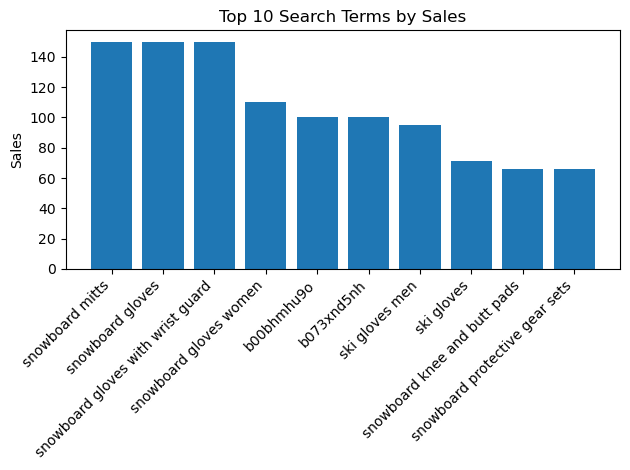

In [16]:
# Top 10 search terms by sales
top10 = df_term.sort_values("sales", ascending=False).head(10)

plt.figure()
plt.bar(top10["search_term"], top10["sales"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Search Terms by Sales")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

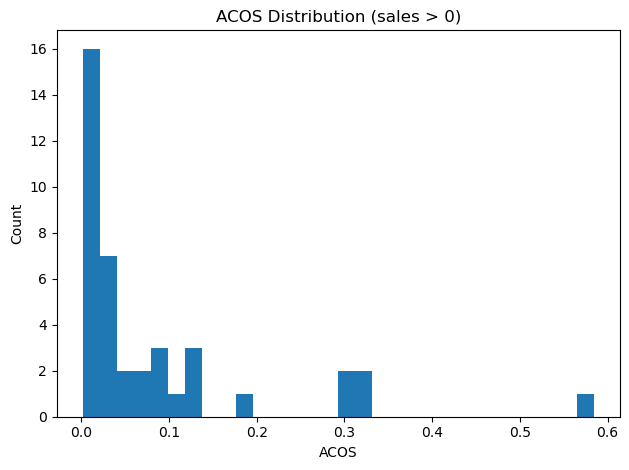

In [17]:
# ACOS distribution (only where sales > 0)
acos_vals = df_term[df_term["sales"] > 0]["ACOS"]

plt.figure()
plt.hist(acos_vals, bins=30)
plt.title("ACOS Distribution (sales > 0)")
plt.xlabel("ACOS")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

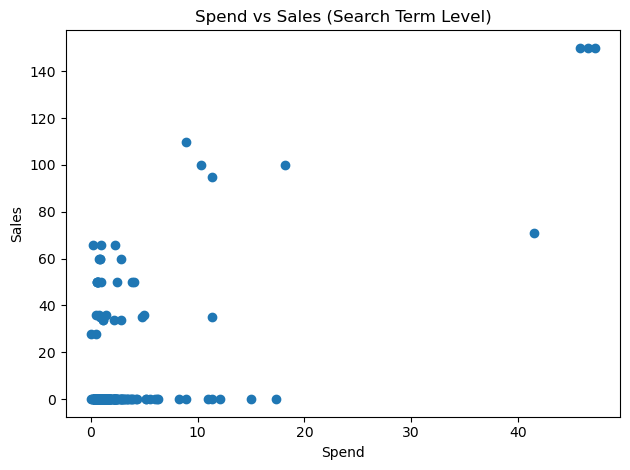

In [18]:
# Spend vs Sales
plt.figure()
plt.scatter(df_term["spend"], df_term["sales"])
plt.title("Spend vs Sales (Search Term Level)")
plt.xlabel("Spend")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

## Visualizations – Interpretation

### Top Search Terms by Sales

The bar chart shows that sales are concentrated in a small number of glove-related search terms (e.g., snowboard/ski gloves variants).  
This pattern suggests clear *core revenue drivers*, where a small subset of search terms contributes disproportionately to total sales.

**Implications**

* Prioritize budget and bid increases on top-performing terms (scalable drivers).
* Consider moving proven terms into Exact match campaigns to stabilize efficiency.
* Use these terms to guide listing optimization (title/bullets) for stronger query-product relevance.

### ACOS Distribution (Sales > 0)

The ACOS histogram is right-skewed: most converting terms fall in a low-ACOS range, while a small number of outliers show much higher ACOS.  
This indicates the account is generally efficient, with a limited set of costly terms that require optimization.

**Implications**

* Maintain and scale low-ACOS converting terms.
* Investigate high-ACOS outliers for bid reduction, match-type tightening, or negative keyword additions.

### Spend vs Sales (Search Term Level)

The scatter plot suggests spend does not translate into sales consistently.  
While a few high-spend terms also generate high sales (scalable opportunities), many terms show non-zero spend with near-zero sales, indicating wasted spend.

**Implications**

* Reduce spend on “spend > 0, sales = 0” terms via negatives/bid cuts.
* For high-spend but low-sales terms, refine targeting or improve landing page relevance.
* Scale the cluster of terms with both high sales and acceptable efficiency (ROAS/ACOS).

# 9) Executive Summary

## Conclusion

This analysis evaluated Amazon Ads search-term performance using sales contribution, ACOS/ROAS efficiency, and spend-to-sales relationships to identify optimization opportunities across campaigns and keyword targeting strategies.

Overall, the advertising account appears **structurally healthy**, with revenue concentrated in a small group of high-performing glove-related search terms. Most converting keywords demonstrate **low ACOS and stable ROAS**, indicating generally efficient advertising performance.

However, the analysis also identified several optimization opportunities:

* A set of waste terms generating clicks but no conversions
* A high-traffic keyword with inefficient cost structure
* Variation in efficiency across campaign types and match types

These findings suggest that performance improvements can be achieved primarily through **targeting refinement rather than increased ad spend**.

---

## Business Recommendations

Based on the analysis, the following actions are recommended:

**1. Reduce wasted spend**

* Add negative keywords from the waste-term segment
* Prioritize terms with the highest spend and zero conversions

**2. Scale high-performing keywords**

* Move proven converting search terms into Exact match campaigns
* Gradually increase bids while monitoring ACOS stability

**3. Optimize inefficient targeting**

* Reduce bids on loss-making keywords
* Review phrase-match performance and targeting relevance
* Reassess targeting-based campaigns with high ACOS

---

## Final Takeaway

The account’s performance is primarily driven by a **small group of scalable, high-efficiency search terms**, while most inefficiencies stem from **low-relevance traffic and broad targeting**.

With targeted bid adjustments, negative keyword implementation, and scaling of proven keywords, the account can likely achieve **higher ROAS without increasing total ad spend**.